<a href="https://colab.research.google.com/github/TrinaBan0807/PythonBasics/blob/main/Identify_color.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload an image:


Saving denim-jacket.webp to denim-jacket (6).webp


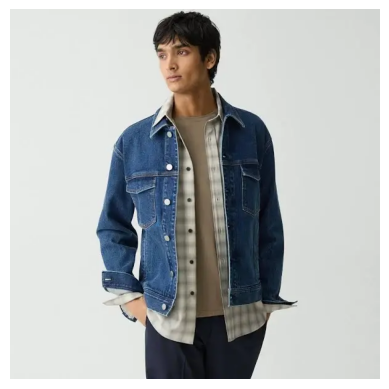

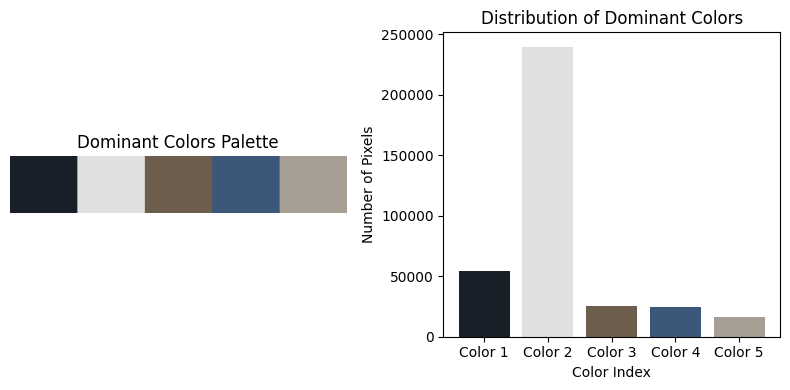

In [1]:
# prompt: Program for image analysis where user uploads the image identify color and show the same in graph

# Install necessary libraries
!pip install opencv-python-headless matplotlib numpy scikit-learn

# Import libraries
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from google.colab import files
import io

# Function to upload and display image
def upload_and_display_image():
    uploaded = files.upload()
    for fn in uploaded.keys():
        img_bytes = uploaded[fn]
        img = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for displaying with matplotlib

        plt.imshow(img)
        plt.axis('off')
        plt.show()
        return img

# Function to analyze color and display in graph
def analyze_and_graph_colors(image, num_colors=5):
    # Reshape the image to be a list of pixels
    pixels = image.reshape((-1, 3))

    # Use KMeans to find dominant colors
    kmeans = KMeans(n_clusters=num_colors, random_state=0, n_init=10) # Added n_init
    kmeans.fit(pixels)
    dominant_colors = kmeans.cluster_centers_.astype(int)
    labels = kmeans.labels_

    # Count the number of pixels for each dominant color
    color_counts = np.bincount(labels)

    # Plot the dominant colors
    plt.figure(figsize=(8, 4))

    # Create a visual representation of the colors
    palette = np.zeros((50, 300, 3), dtype=np.uint8)
    step = 300 // num_colors
    for i in range(num_colors):
        palette[:, i * step: (i + 1) * step, :] = dominant_colors[i]

    plt.subplot(1, 2, 1)
    plt.imshow(palette)
    plt.title('Dominant Colors Palette')
    plt.axis('off')

    # Create a bar chart of color distribution
    plt.subplot(1, 2, 2)
    plt.bar(range(num_colors), color_counts, color=[color / 255.0 for color in dominant_colors])
    plt.title('Distribution of Dominant Colors')
    plt.xlabel('Color Index')
    plt.ylabel('Number of Pixels')
    plt.xticks(range(num_colors), [f'Color {i+1}' for i in range(num_colors)])
    plt.tight_layout()
    plt.show()

# Main execution flow
print("Please upload an image:")
uploaded_image = upload_and_display_image()

if uploaded_image is not None:
    analyze_and_graph_colors(uploaded_image)